In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
data= pd.read_csv('/content/drive/My Drive/Data-Visualization-Project/Traffic.csv')

In [8]:
data.head(5)

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,31,0,4,4,39,low
1,12:15:00 AM,10,Tuesday,49,0,3,3,55,low
2,12:30:00 AM,10,Tuesday,46,0,3,6,55,low
3,12:45:00 AM,10,Tuesday,51,0,2,5,58,low
4,1:00:00 AM,10,Tuesday,57,6,15,16,94,normal


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2976 entries, 0 to 2975
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Time               2976 non-null   object
 1   Date               2976 non-null   int64 
 2   Day of the week    2976 non-null   object
 3   CarCount           2976 non-null   int64 
 4   BikeCount          2976 non-null   int64 
 5   BusCount           2976 non-null   int64 
 6   TruckCount         2976 non-null   int64 
 7   Total              2976 non-null   int64 
 8   Traffic Situation  2976 non-null   object
dtypes: int64(6), object(3)
memory usage: 209.4+ KB


In [10]:
data.describe()

,Date,CarCount,BikeCount,BusCount,TruckCount,Total
count,2976.000000,2976.000000,2976.000000,2976.000000,2976.000000,2976.000000
mean,16.000000,68.696573,14.917339,15.279570,15.324933,114.218414
std,8.945775,45.850693,12.847518,14.341986,10.603833,60.190627
min,1.000000,6.000000,0.000000,0.000000,0.000000,21.000000
25%,8.000000,19.000000,5.000000,1.000000,6.000000,55.000000
50%,16.000000,64.000000,12.000000,12.000000,14.000000,109.000000
75%,24.000000,107.000000,22.000000,25.000000,23.000000,164.000000
max,31.000000,180.000000,70.000000,50.000000,40.000000,279.000000


In [12]:
data.columns

Index(['Time', 'Date', 'Day of the week', 'CarCount', 'BikeCount', 'BusCount',
       'TruckCount', 'Total', 'Traffic Situation'],
      dtype='object')

In [13]:
data.isnull().sum()

,0
Time,0
Date,0
Day of the week,0
CarCount,0
BikeCount,0
BusCount,0
TruckCount,0
Total,0
Traffic Situation,0


In [14]:
data.columns = data.columns.str.strip()

In [16]:
data=data.dropna()

In [17]:
data.head()

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,31,0,4,4,39,low
1,12:15:00 AM,10,Tuesday,49,0,3,3,55,low
2,12:30:00 AM,10,Tuesday,46,0,3,6,55,low
3,12:45:00 AM,10,Tuesday,51,0,2,5,58,low
4,1:00:00 AM,10,Tuesday,57,6,15,16,94,normal


In [18]:
data['Hour'] = pd.to_datetime(data['Time']).dt.hour

/tmp/ipykernel_1099/2607536661.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Hour'] = pd.to_datetime(data['Time']).dt.hour


In [19]:
data[['Time', 'Hour']].head()

,Time,Hour
0,12:00:00 AM,0
1,12:15:00 AM,0
2,12:30:00 AM,0
3,12:45:00 AM,0
4,1:00:00 AM,1


In [20]:
data.head()

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation,Hour
0,12:00:00 AM,10,Tuesday,31,0,4,4,39,low,0
1,12:15:00 AM,10,Tuesday,49,0,3,3,55,low,0
2,12:30:00 AM,10,Tuesday,46,0,3,6,55,low,0
3,12:45:00 AM,10,Tuesday,51,0,2,5,58,low,0
4,1:00:00 AM,10,Tuesday,57,6,15,16,94,normal,1


In [21]:
data.head()

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation,Hour
0,12:00:00 AM,10,Tuesday,31,0,4,4,39,low,0
1,12:15:00 AM,10,Tuesday,49,0,3,3,55,low,0
2,12:30:00 AM,10,Tuesday,46,0,3,6,55,low,0
3,12:45:00 AM,10,Tuesday,51,0,2,5,58,low,0
4,1:00:00 AM,10,Tuesday,57,6,15,16,94,normal,1


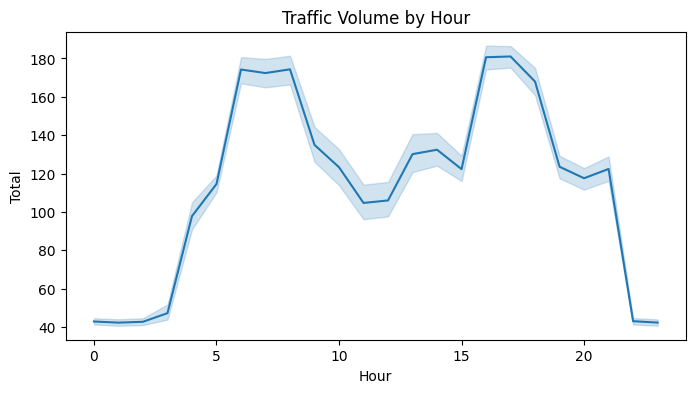

In [26]:
plt.figure(figsize=(8,4))
sns.lineplot(x='Hour', y='Total', data=data)

plt.title("Traffic Volume by Hour")
plt.show()

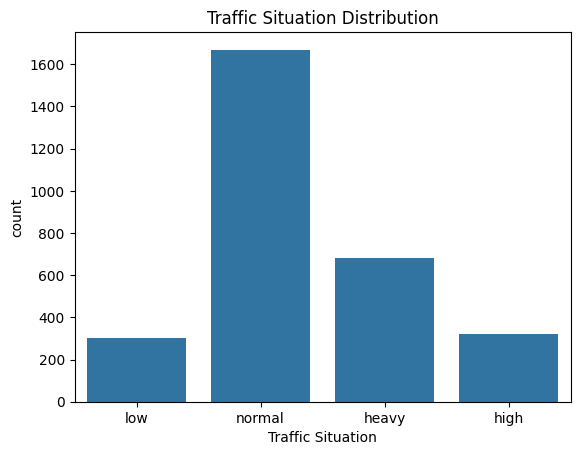

In [27]:
sns.countplot(x='Traffic Situation', data=data)

plt.title("Traffic Situation Distribution")
plt.show()

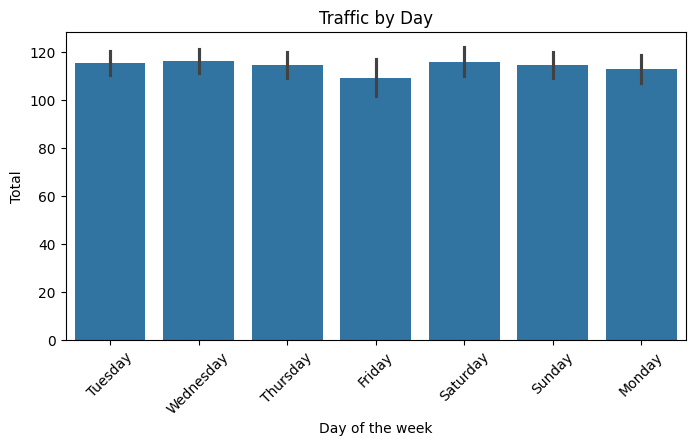

In [28]:
plt.figure(figsize=(8,4))
sns.barplot(x='Day of the week', y='Total', data=data)

plt.xticks(rotation=45)
plt.title("Traffic by Day")
plt.show()

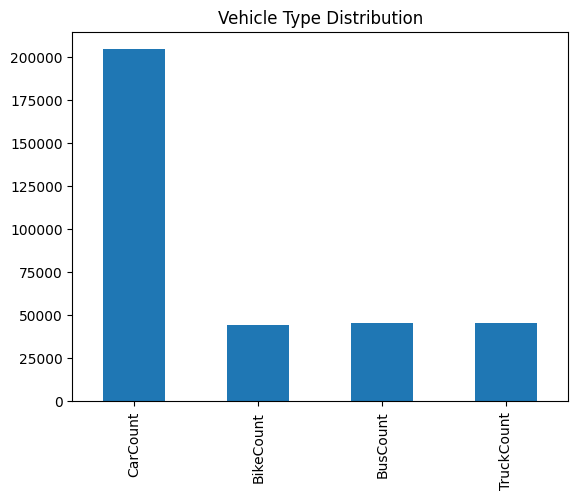

In [29]:
vehicle_data = data[['CarCount', 'BikeCount', 'BusCount', 'TruckCount']].sum()

vehicle_data.plot(kind='bar')

plt.title("Vehicle Type Distribution")
plt.show()

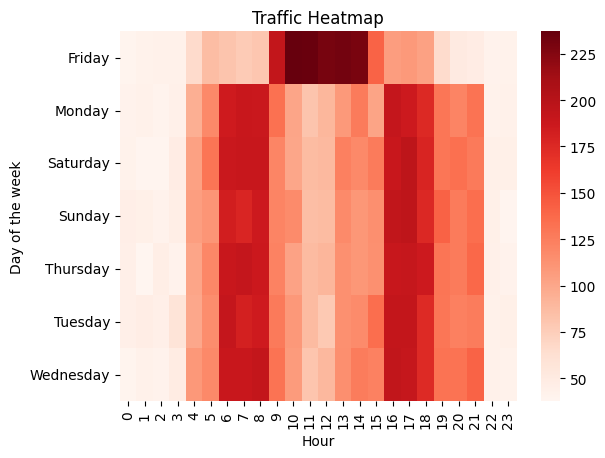

In [30]:
pivot = data.pivot_table(values='Total',
                       index='Day of the week',
                       columns='Hour')

sns.heatmap(pivot, cmap='Reds')

plt.title("Traffic Heatmap")
plt.show()

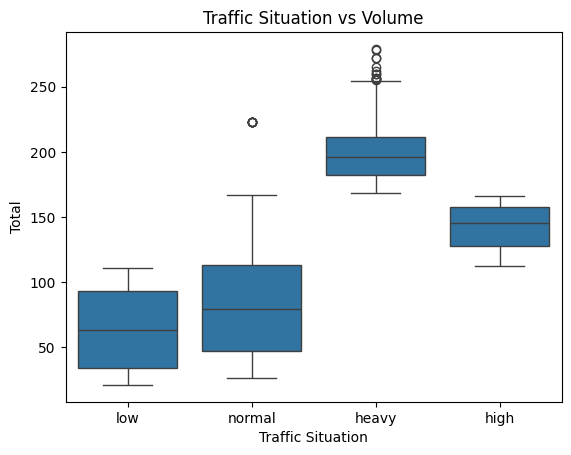

In [31]:
sns.boxplot(x='Traffic Situation', y='Total', data=data)

plt.title("Traffic Situation vs Volume")
plt.show()

In [32]:
data.groupby('Hour')['Total'].mean().sort_values(ascending=False).head()

,Total
Hour,
17,181.048387
16,180.653226
8,174.346774
6,174.250000
7,172.403226


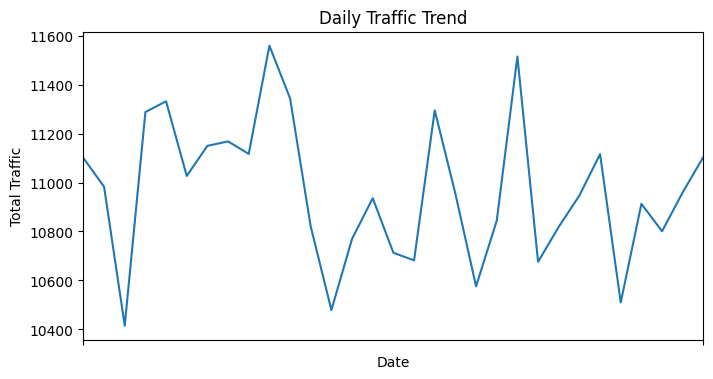

In [35]:
data['Date'] = pd.to_datetime(data['Date'])

daily_traffic = data.groupby('Date')['Total'].sum()

plt.figure(figsize=(8,4))
daily_traffic.plot()

plt.title("Daily Traffic Trend")
plt.xlabel("Date")
plt.ylabel("Total Traffic")

plt.show()

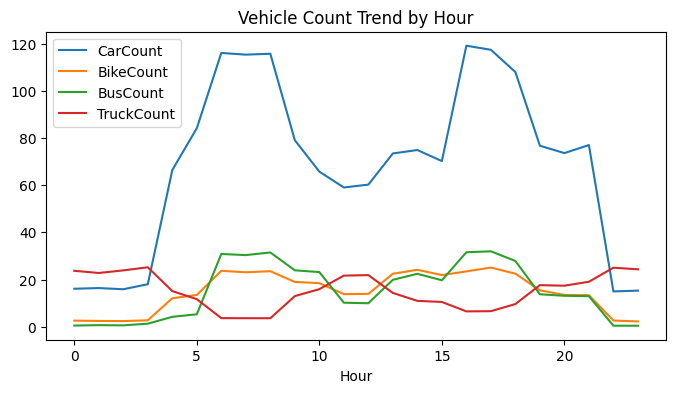

In [36]:
vehicle_trend = data.groupby('Hour')[['CarCount','BikeCount','BusCount','TruckCount']].mean()

vehicle_trend.plot(figsize=(8,4))

plt.title("Vehicle Count Trend by Hour")
plt.show()

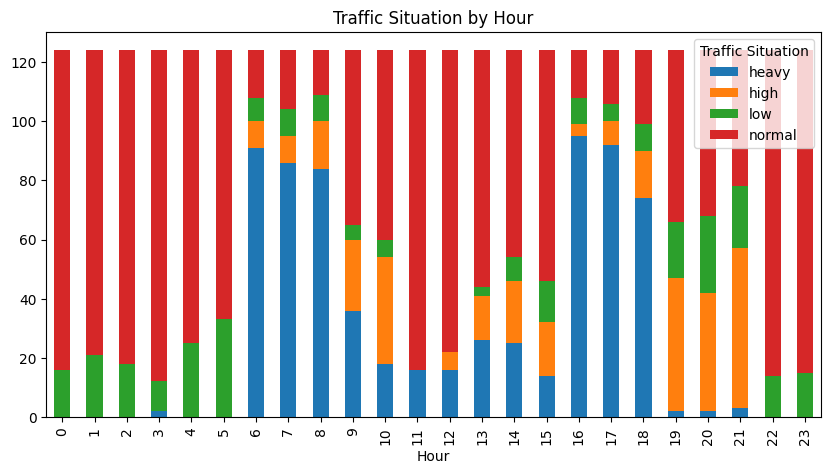

In [37]:
traffic_pivot = data.pivot_table(index='Hour',
                               columns='Traffic Situation',
                               values='Total',
                               aggfunc='count')

traffic_pivot.plot(kind='bar', stacked=True, figsize=(10,5))

plt.title("Traffic Situation by Hour")
plt.show()

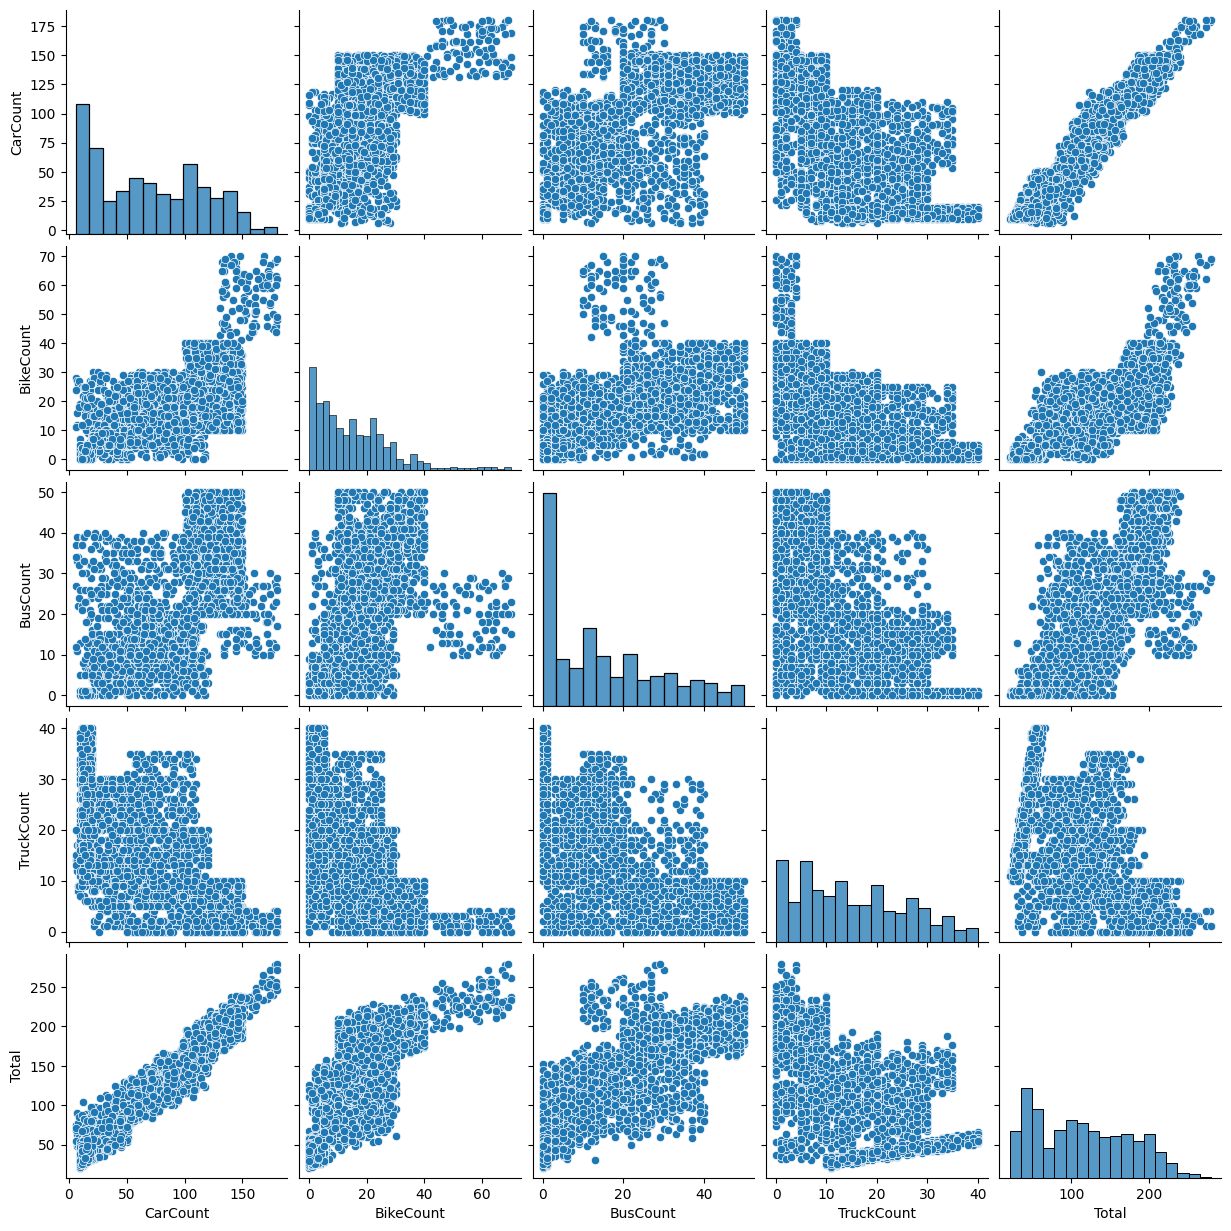

In [38]:
sns.pairplot(data[['CarCount','BikeCount','BusCount','TruckCount','Total']])
plt.show()